# Cognifyz Internship
## Level 3
### Task 1 : Predictive Modeling
Build a regression model to predict the aggregate rating of a restaurant based on available features.
Split the dataset into training and testing sets and evaluate the model's performance using appropriate metrics.
Experiment with different algorithms (e.g.,linear regression, decision trees, randomforest) and compare their performance.

## 1. Importing necessary libararies

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 2. Loading the dataset

In [5]:
df=pd.read_csv("data.csv")
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [7]:
df.tail()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
9546,5915730,Naml۱ Gurme,208,��stanbul,"Kemanke�� Karamustafa Pa��a Mahallesi, R۱ht۱m ...",Karak�_y,"Karak�_y, ��stanbul",28.977392,41.022793,Turkish,...,Turkish Lira(TL),No,No,No,No,3,4.1,Green,Very Good,788
9547,5908749,Ceviz A��ac۱,208,��stanbul,"Ko��uyolu Mahallesi, Muhittin ��st�_nda�� Cadd...",Ko��uyolu,"Ko��uyolu, ��stanbul",29.041297,41.009847,"World Cuisine, Patisserie, Cafe",...,Turkish Lira(TL),No,No,No,No,3,4.2,Green,Very Good,1034
9548,5915807,Huqqa,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.034640,41.055817,"Italian, World Cuisine",...,Turkish Lira(TL),No,No,No,No,4,3.7,Yellow,Good,661
9549,5916112,A���k Kahve,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.036019,41.057979,Restaurant Cafe,...,Turkish Lira(TL),No,No,No,No,4,4.0,Green,Very Good,901
9550,5927402,Walter's Coffee Roastery,208,��stanbul,"Cafea��a Mahallesi, Bademalt۱ Sokak, No 21/B, ...",Moda,"Moda, ��stanbul",29.026016,40.984776,Cafe,...,Turkish Lira(TL),No,No,No,No,2,4.0,Green,Very Good,591


## 3. EDA and Preprocessing

In [10]:
df.info()                                         # Displays information on data type,null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [12]:
df.shape                                                 # Gives the details of number of rows and columns

(9551, 21)

In [14]:
df.dtypes                                              # Displays the data type of each field

Restaurant ID             int64
Restaurant Name          object
Country Code              int64
City                     object
Address                  object
Locality                 object
Locality Verbose         object
Longitude               float64
Latitude                float64
Cuisines                 object
Average Cost for two      int64
Currency                 object
Has Table booking        object
Has Online delivery      object
Is delivering now        object
Switch to order menu     object
Price range               int64
Aggregate rating        float64
Rating color             object
Rating text              object
Votes                     int64
dtype: object

In [16]:
df.columns                                        # Column name of the given dataset will be displayed

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [18]:
df.nunique()                                               # Count of unique values in each field

Restaurant ID           9551
Restaurant Name         7446
Country Code              15
City                     141
Address                 8918
Locality                1208
Locality Verbose        1265
Longitude               8120
Latitude                8677
Cuisines                1825
Average Cost for two     140
Currency                  12
Has Table booking          2
Has Online delivery        2
Is delivering now          2
Switch to order menu       1
Price range                4
Aggregate rating          33
Rating color               6
Rating text                6
Votes                   1012
dtype: int64

In [20]:
df.describe()                                        # Gives the statistical summary of the dataset

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [22]:
df.isnull().sum()                                   # To check the presence of null values

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [24]:
df['Cuisines']=df['Cuisines'].fillna(df['Cuisines'].mode()[0])         # Null Value in field 'Cuisine' is imputed by the mode

In [26]:
df.isnull().sum()                                          # Recheck for null value

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [28]:
df.duplicated().sum()                                   # Checking for duplicate rows in the dataset

0

In [30]:
for col in df.select_dtypes('object'):
    df[col]=df[col].str.replace(r'[^a-zA-Z0-9,]+',"",regex=True)        # Removing special characters from the dataset

In [32]:
df.tail()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
9546,5915730,NamlGurme,208,stanbul,"KemankeKaramustafaPaaMahallesi,RhtmCaddesi,No1...",Karaky,"Karaky,stanbul",28.977392,41.022793,Turkish,...,TurkishLiraTL,No,No,No,No,3,4.1,Green,VeryGood,788
9547,5908749,CevizAac,208,stanbul,"KouyoluMahallesi,MuhittinstndaCaddesi,No85,Kad...",Kouyolu,"Kouyolu,stanbul",29.041297,41.009847,"WorldCuisine,Patisserie,Cafe",...,TurkishLiraTL,No,No,No,No,3,4.2,Green,VeryGood,1034
9548,5915807,Huqqa,208,stanbul,"KuruemeMahallesi,MuallimNaciCaddesi,No56,Beikt...",Kurueme,"Kurueme,stanbul",29.034640,41.055817,"Italian,WorldCuisine",...,TurkishLiraTL,No,No,No,No,4,3.7,Yellow,Good,661
9549,5916112,AkKahve,208,stanbul,"KuruemeMahallesi,MuallimNaciCaddesi,No64B,Beik...",Kurueme,"Kurueme,stanbul",29.036019,41.057979,RestaurantCafe,...,TurkishLiraTL,No,No,No,No,4,4.0,Green,VeryGood,901
9550,5927402,WaltersCoffeeRoastery,208,stanbul,"CafeaaMahallesi,BademaltSokak,No21B,Kadky,stanbul",Moda,"Moda,stanbul",29.026016,40.984776,Cafe,...,TurkishLiraTL,No,No,No,No,2,4.0,Green,VeryGood,591


In [34]:
df['Cuisines']=df['Cuisines'].str.split(',')             # Cuisines are stored as single string in field 'Cuisines' it is split using split()
df=df.explode('Cuisines')                               # For each cuisine separate row is created using explode()

In [36]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,LePetitSouffle,162,MakatiCity,"ThirdFloor,CenturyCityMall,KalayaanAvenue,Pobl...","CenturyCityMall,Poblacion,MakatiCity","CenturyCityMall,Poblacion,MakatiCity,MakatiCity",121.027535,14.565443,French,...,BotswanaPulaP,Yes,No,No,No,3,4.8,DarkGreen,Excellent,314
0,6317637,LePetitSouffle,162,MakatiCity,"ThirdFloor,CenturyCityMall,KalayaanAvenue,Pobl...","CenturyCityMall,Poblacion,MakatiCity","CenturyCityMall,Poblacion,MakatiCity,MakatiCity",121.027535,14.565443,Japanese,...,BotswanaPulaP,Yes,No,No,No,3,4.8,DarkGreen,Excellent,314
0,6317637,LePetitSouffle,162,MakatiCity,"ThirdFloor,CenturyCityMall,KalayaanAvenue,Pobl...","CenturyCityMall,Poblacion,MakatiCity","CenturyCityMall,Poblacion,MakatiCity,MakatiCity",121.027535,14.565443,Desserts,...,BotswanaPulaP,Yes,No,No,No,3,4.8,DarkGreen,Excellent,314
1,6304287,IzakayaKikufuji,162,MakatiCity,"LittleTokyo,2277ChinoRocesAvenue,LegaspiVillag...","LittleTokyo,LegaspiVillage,MakatiCity","LittleTokyo,LegaspiVillage,MakatiCity,MakatiCity",121.014101,14.553708,Japanese,...,BotswanaPulaP,Yes,No,No,No,3,4.5,DarkGreen,Excellent,591
2,6300002,HeatEdsaShangriLa,162,MandaluyongCity,"EdsaShangriLa,1GardenWay,Ortigas,MandaluyongCity","EdsaShangriLa,Ortigas,MandaluyongCity","EdsaShangriLa,Ortigas,MandaluyongCity,Mandaluy...",121.056831,14.581404,Seafood,...,BotswanaPulaP,Yes,No,No,No,4,4.4,Green,VeryGood,270


In [38]:
df['Aggregate rating'].value_counts()                           

Aggregate rating
0.0    3443
3.4    1095
3.5    1079
3.2    1053
3.6    1044
3.3    1018
3.7     979
3.8     972
3.1     971
3.0     857
3.9     856
2.9     710
2.8     663
4.0     659
4.1     648
4.2     558
2.7     541
2.6     419
4.3     412
4.4     370
2.5     265
4.5     227
2.4     205
4.6     186
4.9     116
2.3     100
4.7      98
2.2      58
4.8      52
2.1      40
2.0      17
1.9       6
1.8       2
Name: count, dtype: int64

In [40]:
df=df[df['Aggregate rating']!=0]     # Aggregate rating with value 0 is removed as objective of task is to predict aggregate rating and target value with 0 is not useful.

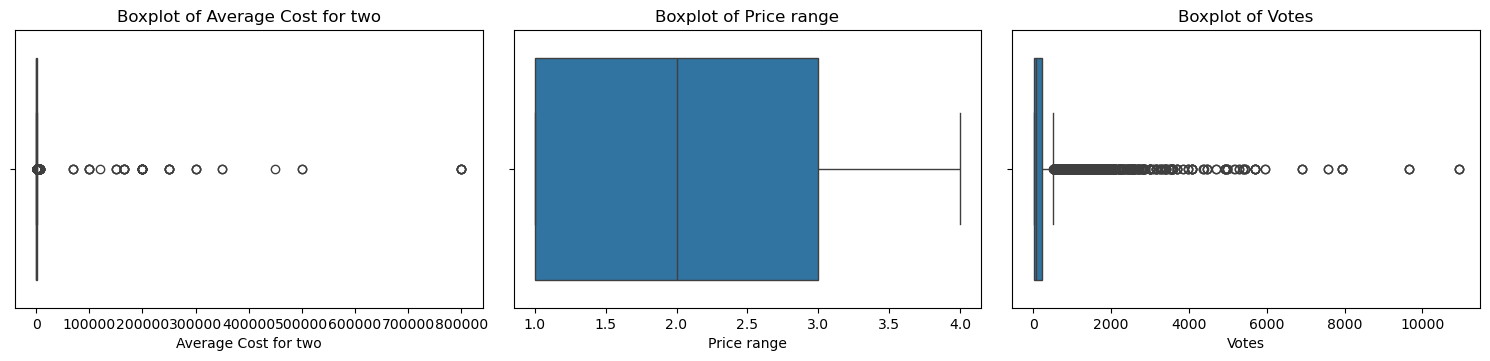

In [42]:
# Outlier detection and handling
features=df.select_dtypes("number").drop(columns=['Restaurant ID','Country Code','Longitude','Latitude','Aggregate rating'])
plt.figure(figsize=(15,10))
for index,col in enumerate(features,1):
    plt.subplot(3,3,index)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

In [44]:
# Outlier is treated by IQR Method
features_to_treat=features.drop(columns='Price range')
for col in features_to_treat:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    df[col]=df[col].clip(lower=lower_bound,upper=upper_bound)

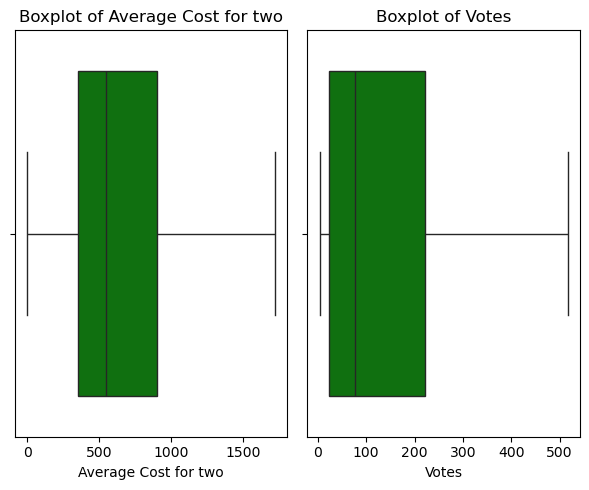

In [46]:
# Visualisation after treating outliers
plt.figure(figsize=(6,5))
for index,col in enumerate(features_to_treat,1):
    plt.subplot(1,2,index)
    sns.boxplot(x=df[col],color='green')
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

In [47]:
# Skewness checking 

In [50]:

for col in features:
    feature_skew=round(df[col].skew(),2)
    print(f"Skewness of '{col}' is :",feature_skew)

Skewness of 'Average Cost for two' is : 0.86
Skewness of 'Price range' is : 0.45
Skewness of 'Votes' is : 1.18


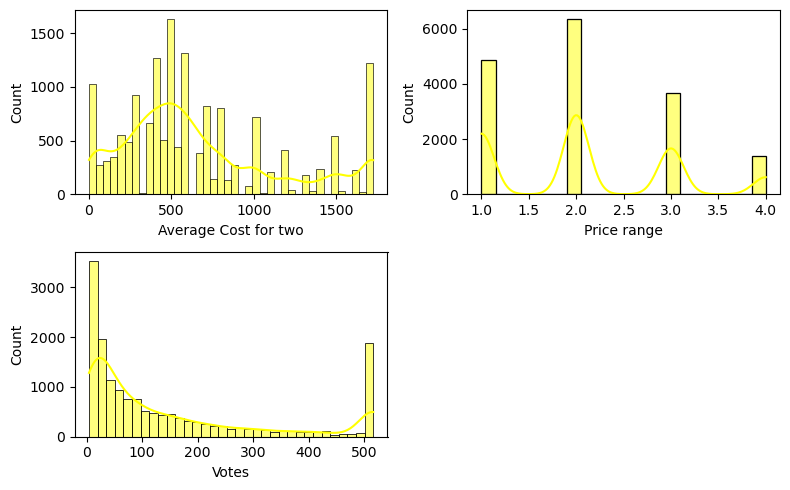

In [52]:
# Visualisation of variables with skewness
plt.figure(figsize=(8,5))
for index,col in enumerate(features,1):
    plt.subplot(2,2,index)
    sns.histplot(data=df[col],kde=True,color='yellow')
plt.tight_layout()
plt.show()

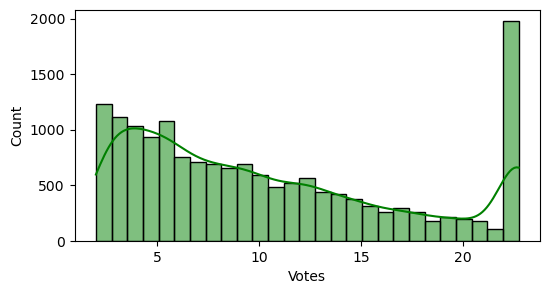

In [53]:
# Treating skewness using sqrt transformation
df['Votes']=np.sqrt(df['Votes'])
plt.figure(figsize=(6,3))
sns.histplot(df['Votes'],kde=True,color='green')
plt.show()

## 4. Feature Engineering

In [57]:
df.drop(columns=['Locality Verbose','Switch to order menu','Locality','Restaurant Name','Address','Restaurant ID','City','Currency','Rating color','Rating text'],inplace=True)  # Dropping columns 'Locality Verbose' and 'Switch to order menu' as it does not contribute to model prediction

In [59]:
df.rename(columns={'Aggregate rating':'Target'},inplace=True)  # Renaming aggregate rating as target

In [61]:
df['Has Table booking'].unique()              

array(['Yes', 'No'], dtype=object)

In [63]:
df['Has Table booking']=df['Has Table booking'].map({'Yes':1,'No':0})   # Categorical variable is converted to binary 0 and 1 using map() for the ML model to understand. 

In [65]:
df['Has Online delivery'].unique()

array(['No', 'Yes'], dtype=object)

In [67]:
df['Has Online delivery']=df['Has Online delivery'].map({'Yes':1,'No':0})  # Categorical variable is converted to binary 0 and 1 using map() for the ML model to understand. 

In [69]:
df['Is delivering now'].unique()

array(['No', 'Yes'], dtype=object)

In [71]:
df['Is delivering now']=df['Is delivering now'].map({'Yes':1,'No':0})       # Categorical variable is converted to binary 0 and 1 using map() for the ML model to understand. 

## 5. Feature Selection

In [74]:
df.columns

Index(['Country Code', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Has Table booking', 'Has Online delivery',
       'Is delivering now', 'Price range', 'Target', 'Votes'],
      dtype='object')

In [76]:
cuisines = df['Cuisines'].unique().tolist()
print(cuisines)

['French', 'Japanese', 'Desserts', 'Seafood', 'Asian', 'Filipino', 'Indian', 'Sushi', 'Korean', 'Chinese', 'European', 'Mexican', 'American', 'IceCream', 'Cafe', 'Italian', 'Pizza', 'Bakery', 'Mediterranean', 'FastFood', 'Brazilian', 'Arabian', 'BarFood', 'Grill', 'International', 'Peruvian', 'LatinAmerican', 'Burger', 'Juices', 'HealthyFood', 'Beverages', 'Lebanese', 'Sandwich', 'Steak', 'BBQ', 'GourmetFastFood', 'NorthEastern', 'NorthIndian', 'CoffeeandTea', 'Vegetarian', 'Tapas', 'Breakfast', 'Diner', 'Southern', 'Southwestern', 'Spanish', 'Argentine', 'Caribbean', 'German', 'Vietnamese', 'Thai', 'ModernAustralian', 'Teriyaki', 'Cajun', 'Canadian', 'TexMex', 'MiddleEastern', 'Greek', 'BubbleTea', 'Tea', 'Australian', 'Fusion', 'Cuban', 'Hawaiian', 'Salad', 'Irish', 'NewAmerican', 'SoulFood', 'Turkish', 'PubFood', 'Continental', 'Singaporean', 'Malay', 'Cantonese', 'DimSum', 'Western', 'FingerFood', 'British', 'Deli', 'Indonesian', 'Mughlai', 'Biryani', 'SouthIndian', 'Pakistani', 'A

In [78]:
def cuisine_map(cuisines):
    
    if cuisines.lower() in (['indian','northindian','southindian','mughlai','biryani','hyderabadi',
    'rajasthani','goan','gujarati','maharashtrian','modernindian','chettinad','parsi','kerala','kashmiri','bengali',
    'lucknowi','awadhi','oriya','bihari','assamese','andhra','mangalorean','malwani','naga','mithai','curry','vegetarian','northeastern']):
        return "Indian"
    
    elif cuisines.lower() in (['japanese','filipino','sushi','korean','chinese','asian','vietnamese','thai','teriyaki','singaporean','malay',
    'cantonese','dimsum','indonesian','burmese','tibetan','nepalese','srilankan','peranakan','sunda','ramen','taiwanese','asianfusion']):
         return "Asian"

    elif cuisines.lower() in (['arabian','lebanese','middleeastern','turkish','persian','iranian','moroccan','afghani','pakistani',
    'african','southafrican','durban','kebab','turkishpizza','izgara']):
        return "Middle_east"

    elif cuisines.lower() in (['french','italian','pizza','mediterranean','spanish','german','greek','continental','british',
    'portuguese','armenian','belgian','scottish','irish','patisserie','fishandchips']):
        return "European"

    elif cuisines.lower() in (['mexican','american','brazilian','peruvian','latinamerican','argentine','caribbean','cajun','canadian',
    'texmex','australian','modernaustralian','kiwi','cuban','hawaiian','newamerican','soulfood','southern','southwestern','western']):
         return "Western"

    else:
        return "Others"

In [80]:
df['Cuisines']=df['Cuisines'].apply(cuisine_map)

In [82]:
df['Cuisines'].unique()

array(['European', 'Asian', 'Others', 'Indian', 'Western', 'Middle_east'],
      dtype=object)

In [84]:
df.columns

Index(['Country Code', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Has Table booking', 'Has Online delivery',
       'Is delivering now', 'Price range', 'Target', 'Votes'],
      dtype='object')

In [86]:
# Encoding categorical featues using OneHotEncoding
df=pd.get_dummies(df,columns=['Cuisines'],drop_first=True)
df.head()

,Country Code,Longitude,Latitude,Average Cost for two,Has Table booking,Has Online delivery,Is delivering now,Price range,Target,Votes,Cuisines_European,Cuisines_Indian,Cuisines_Middle_east,Cuisines_Others,Cuisines_Western
0,162,121.027535,14.565443,1100,1,0,0,3,4.8,17.720045,True,False,False,False,False
0,162,121.027535,14.565443,1100,1,0,0,3,4.8,17.720045,False,False,False,False,False
0,162,121.027535,14.565443,1100,1,0,0,3,4.8,17.720045,False,False,False,True,False
1,162,121.014101,14.553708,1200,1,0,0,3,4.5,22.726636,False,False,False,False,False
2,162,121.056831,14.581404,1725,1,0,0,4,4.4,16.431677,False,False,False,True,False


In [88]:
num_feature=['Longitude','Latitude','Average Cost for two','Has Table booking','Has Online delivery','Is delivering now','Price range','Target']
df_num_features=df[num_feature]
df_num_features

,Longitude,Latitude,Average Cost for two,Has Table booking,Has Online delivery,Is delivering now,Price range,Target
0,121.027535,14.565443,1100,1,0,0,3,4.8
0,121.027535,14.565443,1100,1,0,0,3,4.8
0,121.027535,14.565443,1100,1,0,0,3,4.8
1,121.014101,14.553708,1200,1,0,0,3,4.5
2,121.056831,14.581404,1725,1,0,0,4,4.4
...,...,...,...,...,...,...,...,...
9547,29.041297,41.009847,105,0,0,0,3,4.2
9548,29.034640,41.055817,170,0,0,0,4,3.7
9548,29.034640,41.055817,170,0,0,0,4,3.7
9549,29.036019,41.057979,120,0,0,0,4,4.0


In [90]:
correlation_matrix=df_num_features.corr()        # Correlation between numerical feature with Target is found
correlation_matrix 

,Longitude,Latitude,Average Cost for two,Has Table booking,Has Online delivery,Is delivering now,Price range,Target
Longitude,1.000000,-0.075681,0.334910,0.131700,0.207495,0.022872,-0.048039,-0.265329
Latitude,-0.075681,1.000000,-0.027303,0.062473,0.129058,0.018496,-0.225608,-0.188005
Average Cost for two,0.334910,-0.027303,1.000000,0.626694,0.077725,0.011937,0.697224,0.178165
Has Table booking,0.131700,0.062473,0.626694,1.000000,0.048035,-0.030562,0.482965,0.123866
Has Online delivery,0.207495,0.129058,0.077725,0.048035,1.000000,0.105194,-0.043678,-0.086052
Is delivering now,0.022872,0.018496,0.011937,-0.030562,0.105194,1.000000,-0.004454,-0.023133
Price range,-0.048039,-0.225608,0.697224,0.482965,-0.043678,-0.004454,1.000000,0.398284
Target,-0.265329,-0.188005,0.178165,0.123866,-0.086052,-0.023133,0.398284,1.000000


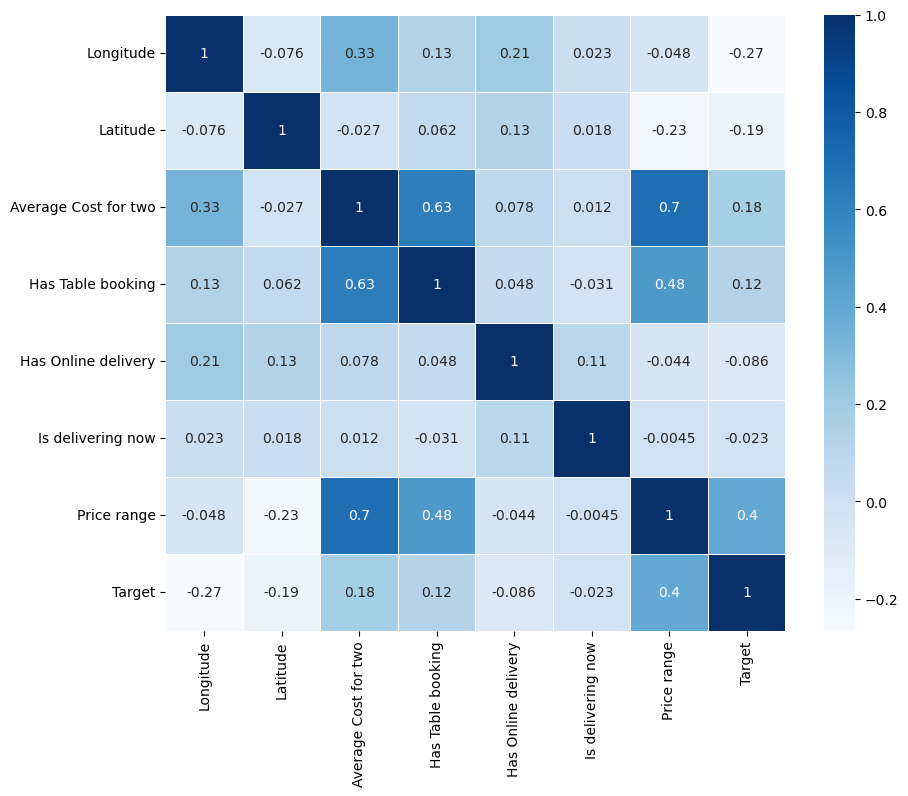

In [92]:
# Visualisation of correlation of variables
plt.figure(figsize=(10,8))
sns.heatmap(data=correlation_matrix,annot=True,fmt='.2g',linewidth=0.5,cmap='Blues')
plt.show()

In [94]:
relation_with_target=df_num_features.corr()[['Target']].abs().sort_values(by='Target',ascending=False)
relation_with_target

,Target
Target,1.000000
Price range,0.398284
Longitude,0.265329
Latitude,0.188005
Average Cost for two,0.178165
Has Table booking,0.123866
Has Online delivery,0.086052
Is delivering now,0.023133


In [96]:
# Dropping variables with low relation to target
low_relation=relation_with_target[relation_with_target['Target']<.10].index.tolist()
low_relation

['Has Online delivery', 'Is delivering now']

In [98]:
df.drop(columns=low_relation,inplace=True)        # Dropping features that has low relation with target
df.head()

,Country Code,Longitude,Latitude,Average Cost for two,Has Table booking,Price range,Target,Votes,Cuisines_European,Cuisines_Indian,Cuisines_Middle_east,Cuisines_Others,Cuisines_Western
0,162,121.027535,14.565443,1100,1,3,4.8,17.720045,True,False,False,False,False
0,162,121.027535,14.565443,1100,1,3,4.8,17.720045,False,False,False,False,False
0,162,121.027535,14.565443,1100,1,3,4.8,17.720045,False,False,False,True,False
1,162,121.014101,14.553708,1200,1,3,4.5,22.726636,False,False,False,False,False
2,162,121.056831,14.581404,1725,1,4,4.4,16.431677,False,False,False,True,False


In [100]:
# Dropping variables with high relation
high_relation=relation_with_target[relation_with_target['Target']>=0.90].index.tolist()
high_relation.remove('Target')
high_relation

[]

## 7.Splitting into X and Y

In [103]:
X=df.drop(columns='Target')
y=df['Target']

## 8.Splitting into test and train data

In [106]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

## 9.Feature Scaling

In [109]:
# Scaling is performed using standard scaler
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
X_train_scaled=ss.fit_transform(X_train)
X_test_scaled=ss.transform(X_test)

## 10. Model Selction and Matrix Evaluation

In [112]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
models={'Linear Regression':LinearRegression(),
'Decision Tree Regressor':DecisionTreeRegressor(),
'Random Forest Regressor':RandomForestRegressor()}
for name,model in models.items():
    model.fit(X_train_scaled,y_train)
    y_predt=model.predict(X_test_scaled)
    print(f"\nPerformance of {name}\n")
    print("MSE:", round(mean_squared_error(y_test,y_predt),2))
    print("MAE:",round(mean_absolute_error(y_test,y_predt),2))
    print("RMSE:",round(np.sqrt(mean_squared_error(y_test,y_predt)),2))
    print("R2 Score",round(r2_score(y_test,y_predt),2))


Performance of Linear Regression

MSE: 0.16
MAE: 0.3
RMSE: 0.4
R2 Score 0.48

Performance of Decision Tree Regressor

MSE: 0.09
MAE: 0.13
RMSE: 0.3
R2 Score 0.71

Performance of Random Forest Regressor

MSE: 0.05
MAE: 0.15
RMSE: 0.23
R2 Score 0.83


Comment :
- Random Forest is the best model here with high R2 score and lower error